## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_ID = 'EL52'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc)
dataset_monthly

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases
0,22.215876,40.552658,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,4.435606,6.168909,2.702302,-0.015091,12.092545,6.794681,NaN,NaN,NaN,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,81.134845,15.306163,25.795942,35.973005,11806.0,44835.0,13866.0,70507.0,11360.0,44584.0,16384.0,72328.0,2016.25,NaN,NaN,1043.454545,0
1,23.139532,40.695359,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,4.816764,7.923406,1.710122,-2.877717,13.860079,6.961915,NaN,NaN,NaN,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,42.311748,7.807795,13.338001,19.783772,87330.0,375115.0,82051.0,544496.0,84172.0,402246.0,107376.0,593794.0,19627.51,NaN,NaN,740.125984,0
2,22.758634,41.016242,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,3.765541,7.190461,0.340620,-4.895934,12.183407,5.888491,NaN,NaN,NaN,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,53.173589,9.279576,14.213017,18.993597,5963.0,24603.0,9769.0,40335.0,5680.0,23436.0,11889.0,41005.0,1124.52,NaN,NaN,631.285714,0
3,22.109199,40.888821,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,3.694941,6.414831,0.975051,-3.823409,11.261136,6.293877,NaN,NaN,NaN,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,81.491186,14.713423,22.905129,32.657020,11159.0,44537.0,14694.0,70390.0,11052.0,43212.0,17690.0,71954.0,1938.34,NaN,NaN,869.318182,0
4,22.441443,40.269748,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL525,πιερια,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,6.091283,8.354315,3.828251,1.550444,15.961111,8.601499,NaN,NaN,NaN,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,81.927242,15.859868,27.160592,39.731443,10433.0,40170.0,12062.0,62665.0,10152.0,40273.0,14620.0,65045.0,1725.03,NaN,NaN,1130.755556,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,22.758634,41.016242,12,2022,2022-12,EL52,κεντρικη μακεδονια,EL523,κιλκις,0.248495,-0.068467,-0.235479,0.068467,0.235742,-0.051754,-0.226094,0.051754,0.043100,0.039837,0.035631,0.039837,16.833333,22.500000,45.000000,900.084171,42.0,-8.0,50.0,

<AxesSubplot:>

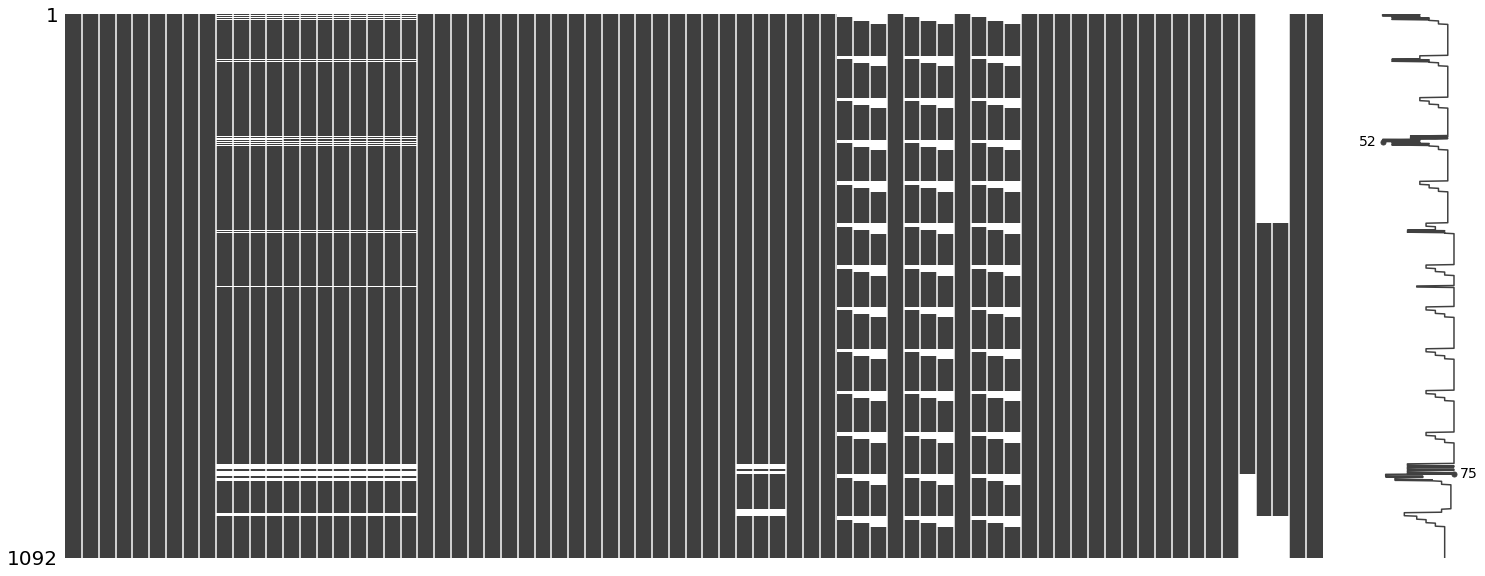

In [4]:
missingno.matrix(dataset_monthly)

In [5]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
0,ndvi,5.2198
1,ndmi,5.2198
2,ndwi,5.2198
3,ndbi,5.2198
4,ndvi_mean,5.1282
...,...,...
22,lst_mar_night_mean,16.6667
23,lst_apr_night_mean,25.0000
24,MIO_EUR,15.3846
25,L_TOTAL,46.1538


In [6]:
years = dataset_monthly.year.unique()
nuts3_units = dataset_monthly.NUTS3_NAME.unique()

In [7]:
data = []

for year in years:
    for region in nuts3_units:
        filtered_df = dataset_monthly.loc[(dataset_monthly['year'] == year) & (dataset_monthly['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        q1_df = filtered_df.loc[(filtered_df['month'] <= 3)]
        q2_df = filtered_df.loc[(filtered_df['month'] <= 6)]
        q3_df = filtered_df.loc[(filtered_df['month'] <= 9)]
        q4_df = filtered_df.loc[(filtered_df['month'] <= 12)]

        min_temp_q1 = q1_df['lst'].min()
        mean_temp_q1 = q1_df['lst'].mean()
        max_temp_q1 = q1_df['lst'].max()
        prec_q1 = q1_df['rainfall'].sum()

        ndvi_q1 = q1_df['ndvi'].mean()
        ndwi_q1 = q1_df['ndwi'].mean()
        ndmi_q1 = q1_df['ndmi'].mean()
        ndbi_q1 = q1_df['ndbi'].mean()

        ndvi_mean_q1 = q1_df['ndvi_mean'].mean()
        ndwi_mean_q1 = q1_df['ndwi_mean'].mean()
        ndmi_mean_q1 = q1_df['ndmi_mean'].mean()
        ndbi_mean_q1 = q1_df['ndbi_mean'].mean()

        ndvi_std_q1 = q1_df['ndvi_std'].mean()
        ndwi_std_q1 = q1_df['ndwi_std'].mean()
        ndmi_std_q1 = q1_df['ndmi_std'].mean()
        ndbi_std_q1 = q1_df['ndbi_std'].mean()

        min_temp_q2 = q2_df['lst'].min()
        mean_temp_q2 = q2_df['lst'].mean()
        max_temp_q2 = q2_df['lst'].max()
        prec_q2 = q2_df['rainfall'].sum()

        ndvi_q2 = q2_df['ndvi'].mean()
        ndwi_q2 = q2_df['ndwi'].mean()
        ndmi_q2 = q2_df['ndmi'].mean()
        ndbi_q2 = q2_df['ndbi'].mean()

        ndvi_mean_q2 = q2_df['ndvi_mean'].mean()
        ndwi_mean_q2 = q2_df['ndwi_mean'].mean()
        ndmi_mean_q2 = q2_df['ndmi_mean'].mean()
        ndbi_mean_q2 = q2_df['ndbi_mean'].mean()

        ndvi_std_q2 = q2_df['ndvi_std'].mean()
        ndwi_std_q2 = q2_df['ndwi_std'].mean()
        ndmi_std_q2 = q2_df['ndmi_std'].mean()
        ndbi_std_q2 = q2_df['ndbi_std'].mean()

        min_temp_q3 = q3_df['lst'].min()
        mean_temp_q3 = q3_df['lst'].mean()
        max_temp_q3 = q3_df['lst'].max()
        prec_q3 = q3_df['rainfall'].sum()

        ndvi_q3 = q3_df['ndvi'].mean()
        ndwi_q3 = q3_df['ndwi'].mean()
        ndmi_q3 = q3_df['ndmi'].mean()
        ndbi_q3 = q3_df['ndbi'].mean()

        ndvi_mean_q3 = q3_df['ndvi_mean'].mean()
        ndwi_mean_q3 = q3_df['ndwi_mean'].mean()
        ndmi_mean_q3 = q3_df['ndmi_mean'].mean()
        ndbi_mean_q3 = q3_df['ndbi_mean'].mean()

        ndvi_std_q3 = q3_df['ndvi_std'].mean()
        ndwi_std_q3 = q3_df['ndwi_std'].mean()
        ndmi_std_q3 = q3_df['ndmi_std'].mean()
        ndbi_std_q3 = q3_df['ndbi_std'].mean()

        min_temp_q4 = q4_df['lst'].min()
        mean_temp_q4 = q4_df['lst'].mean()
        max_temp_q4 = q4_df['lst'].max()
        prec_q4 = q4_df['rainfall'].sum()

        ndvi_q4 = q4_df['ndvi'].mean()
        ndwi_q4 = q4_df['ndwi'].mean()
        ndmi_q4 = q4_df['ndmi'].mean()
        ndbi_q4 = q4_df['ndbi'].mean()

        ndvi_mean_q4 = q4_df['ndvi_mean'].mean()
        ndwi_mean_q4 = q4_df['ndwi_mean'].mean()
        ndmi_mean_q4 = q4_df['ndmi_mean'].mean()
        ndbi_mean_q4 = q4_df['ndbi_mean'].mean()

        ndvi_std_q4 = q4_df['ndvi_std'].mean()
        ndwi_std_q4 = q4_df['ndwi_std'].mean()
        ndmi_std_q4 = q4_df['ndmi_std'].mean()
        ndbi_std_q4 = q4_df['ndbi_std'].mean()

        data.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'min_temp_q1': min_temp_q1,
                     'mean_temp_q1': mean_temp_q1,
                     'max_temp_q1': max_temp_q1,
                     'prec_q1': prec_q1,
                     'ndvi_q1': ndvi_q1,
                     'ndwi_q1': ndwi_q1,
                     'ndmi_q1': ndmi_q1,
                     'ndbi_q1': ndbi_q1,
                     'ndvi_mean_q1': ndvi_mean_q1,
                     'ndwi_mean_q1': ndwi_mean_q1,
                     'ndmi_mean_q1': ndmi_mean_q1,
                     'ndbi_mean_q1': ndbi_mean_q1,
                     'ndvi_std_q1': ndvi_std_q1,
                     'ndwi_std_q1': ndwi_std_q1,
                     'ndmi_std_q1': ndmi_std_q1,
                     'ndbi_std_q1': ndbi_std_q1,
                     'min_temp_q2': min_temp_q2,
                     'mean_temp_q2': mean_temp_q2,
                     'max_temp_q2': max_temp_q2,
                     'prec_q2': prec_q2,
                     'ndvi_q2': ndvi_q2,
                     'ndwi_q2': ndwi_q2,
                     'ndmi_q2': ndmi_q2,
                     'ndbi_q2': ndbi_q2,
                     'ndvi_mean_q2': ndvi_mean_q2,
                     'ndwi_mean_q2': ndwi_mean_q2,
                     'ndmi_mean_q2': ndmi_mean_q2,
                     'ndbi_mean_q2': ndbi_mean_q2,
                     'ndvi_std_q2': ndvi_std_q2,
                     'ndwi_std_q2': ndwi_std_q2,
                     'ndmi_std_q2': ndmi_std_q2,
                     'ndbi_std_q2': ndbi_std_q2,
                     'min_temp_q3': min_temp_q3,
                     'mean_temp_q3': mean_temp_q3,
                     'max_temp_q3': max_temp_q3,
                     'prec_q3': prec_q3,
                     'ndvi_q3': ndvi_q3,
                     'ndwi_q3': ndwi_q3,
                     'ndmi_q3': ndmi_q3,
                     'ndbi_q3': ndbi_q3,
                     'ndvi_mean_q3': ndvi_mean_q3,
                     'ndwi_mean_q3': ndwi_mean_q3,
                     'ndmi_mean_q3': ndmi_mean_q3,
                     'ndbi_mean_q3': ndbi_mean_q3,
                     'ndvi_std_q3': ndvi_std_q3,
                     'ndwi_std_q3': ndwi_std_q3,
                     'ndmi_std_q3': ndmi_std_q3,
                     'ndbi_std_q3': ndbi_std_q3,
                     'min_temp_q4': min_temp_q4,
                     'mean_temp_q4': mean_temp_q4,
                     'max_temp_q4': max_temp_q4,
                     'prec_q4': prec_q4,
                     'ndvi_q4': ndvi_q4,
                     'ndwi_q4': ndwi_q4,
                     'ndmi_q4': ndmi_q4,
                     'ndbi_q4': ndbi_q4,
                     'ndvi_mean_q4': ndvi_mean_q4,
                     'ndwi_mean_q4': ndwi_mean_q4,
                     'ndmi_mean_q4': ndmi_mean_q4,
                     'ndbi_mean_q4': ndbi_mean_q4,
                     'ndvi_std_q4': ndvi_std_q4,
                     'ndwi_std_q4': ndwi_std_q4,
                     'ndmi_std_q4': ndmi_std_q4,
                     'ndbi_std_q4': ndbi_std_q4})
        
q_df = pd.DataFrame(data)        

In [8]:
q_df

,NUTS3_NAME,year,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,ημαθια,2010,4.053816,6.095815,9.798023,16.614763,0.306789,-0.138970,0.153101,-0.153101,0.299181,-0.144685,0.139387,-0.139387,0.042870,0.048620,0.046756,0.046756,4.053816,12.714621,22.854273,26.302324,0.467335,-0.264430,0.183711,-0.183711,0.462333,-0.265378,0.176747,-0.176747,0.049947,0.037574,0.048033,0.048033,4.053816,16.345998,26.201021,33.540369,0.513696,-0.298184,0.196802,-0.196802,0.507719,-0.296658,0.191635,-0.191635,0.055679,0.034079,0.052140,0.052140,4.017889,14.575072,26.201021,52.594557,0.474099,-0.245552,0.202110,-0.202110,0.467210,-0.242613,0.197819,-0.197819,0.053380,0.038996,0.051146,0.051146
1,θεσσαλονικη,2010,4.816764,7.030397,10.519632,13.670895,0.245236,0.030018,0.236393,-0.236393,0.241640,0.031126,0.234157,-0.234157,0.048755,0.076113,0.060924,0.060924,4.816764,13.515330,23.514276,22.845725,0.337155,-0.120451,0.190933,-0.190933,0.329974,-0.115169,0.188722,-0.188722,0.051948,0.059625,0.055771,0.055771,4.816764,17.777812,29.026246,28.046688,0.348850,-0.177214,0.153486,-0.153486,0.341657,-0.168365,0.154419,-0.154419,0.054679,0.057935,0.057141,0.057141,4.816764,16.021933,29.026246,44.686314,0.340091,-0.167727,0.150633,-0.150633,0.332144,-0.159501,0.150750,-0.150750,0.056088,0.060716,0.058329,0.058329
2,κιλκις,2010,3.765541,6.584831,10.513570,11.680117,0.174434,0.244420,0.391708,-0.391708,0.184454,0.205833,0.365953,-0.365953,0.030962,0.057655,0.035276,0.035276,3.765541,13.320929,24.146919,21.476997,0.312265,-0.034495,0.259898,-0.259898,0.319819,-0.049773,0.252871,-0.252871,0.042066,0.044326,0.042829,0.042829,3.765541,17.689295,29.333807,28.039143,0.340454,-0.135932,0.192746,-0.192746,0.344876,-0.146274,0.187945,-0.187945,0.046582,0.042927,0.046710,0.046710,3.765541,15.755756,29.333807,47.013438,0.327792,-0.152513,0.161695,-0.161695,0.330502,-0.157381,0.159993,-0.159993,0.047501,0.043448,0.047940,0.047940
3,πελλα,2010,3.694941,5.985560,9.966311,15.621303,0.360526,-0.246280,0.100091,-0.100091,0.353132,-0.247511,0.093680,-0.093680,0.049693,0.055187,0.057223,0.057223,3.694941,12.460529,22.550288,26.291151,0.470341,-0.292879,0.158259,-0.158259,0.464910,-0.285272,0.160761,-0.160761,0.051947,0.042915,0.051677,0.051677,3.694941,16.365521,27.057390,33.702197,0.510639,-0.311854,0.178125,-0.178125,0.504519,-0.304798,0.179316,-0.179316,0.053080,0.039084,0.052466,0.052466,3.656815,14.576237,27.057390,54.202848,0.474200,-0.267804,0.180605,-0.180605,0.469926,-0.260996,0.183069,-0.183069,0.051877,0.043944,0.052852,0.052852
4,πιερια,2010,5.781394,7.565705,10.824437,15.959433,0.342582,-0.245848,0.087959,-0.087959,0.332714,-0.204177,0.108954,-0.108954,0.041787,0.049893,0.044767,0.044767,5.781394,13.321219,22.806607,24.779606,0.453144,-0.284769,0.153494,-0.153494,0.449325,-0.263081,0.165668,-0.165668,0.057696,0.038189,0.052645,0.052645,5.781394,17.300530,27.922839,32.606561,0.461398,-0.305094,0.143938,-0.143938,0.458288,-0.289777,0.152805,-0.152805,0.062582,0.036228,0.056970,0.056970,5.662272,15.650330,27.922839,48.945308,0.430975,-0.257275,0.153887,-0.153887,0.425644,-0.241135,0.161653,-0.161653,0.061936,0.046036,0.059592,0.059592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [9]:
dataset_monthly = pd.merge(dataset_monthly, q_df,  how='left', on=['NUTS3_NAME', 'year'])

In [10]:
dataset_monthly

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,22.215876,40.552658,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,4.435606,6.168909,2.702302,-0.015091,12.092545,6.794681,NaN,NaN,NaN,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,81.134845,15.306163,25.795942,35.973005,11806.0,44835.0,13866.0,70507.0,11360.0,44584.0,16384.0,72328.0,2016.25,NaN,NaN,1043.454545,0,4.053816,6.095815,9.798023,16.614763,0.306789,-0.138970,0.153101,-0.153101,0.299181,-0.144685,0.139387,-0.139387,0.042870,0.048620,0.046756,0.046756,4.053816,12.714621,22.854273,26.302324,0.467335,-0.264430,0.183711,-0.183711,0.462333,-0.265378,0.176747,-0.176747,0.049947,0.037574,0.048033,0.048033,4.053816,16.345998,26.201021,33.540369,0.513696,-0.298184,0.196802,-0.196802,0.507719,-0.296658,0.191635,-0.191635,0.055679,0.034079,0.052140,0.052140,4.017889,14.575072,26.201021,52.594557,0.474099,-0.245552,0.202110,-0.202110,0.467210,-0.242613,0.197819,-0.197819,0.053380,0.038996,0.051146,0.051146
1,23.139532,40.695359,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,4.816764,7.923406,1.710122,-2.877717,13.860079,6.961915,NaN,NaN,NaN,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,42.311748,7.807795,13.338001,19.783772,87330.0,375115.0,82051.0,544496.0,84172.0,402246.0,107376.0,593794.0,19627.51,NaN,NaN,740.125984,0,4.816764,7.030397,10.519632,13.670895,0.245236,0.030018,0.236393,-0.236393,0.241640,0.031126,0.234157,-0.234157,0.048755,0.076113,0.060924,0.060924,4.816764,13.515330,23.514276,22.845725,0.337155,-0.120451,0.190933,-0.190933,0.329974,-0.115169,0.188722,-0.188722,0.051948,0.059625,0.055771,0.055771,4.816764,17.777812,29.026246,28.046688,0.348850,-0.177214,0.153486,-0.153486,0.341657,-0.168365,0.154419,-0.154419,0.054679,0.057935,0.057141,0.057141,4.816764,16.021933,29.026246,44.686314,0.340091,-0.167727,0.150633,-0.150633,0.332144,-0.159501,0.150750,-0.150750,0.056088,0.060716,0.058329,0.058329
2,22.758634,41.016242,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667

In [11]:
grouped_annualy = dataset_monthly.groupby(['year', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_annual = grouped_annualy.mean()
dataset_annual.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2010,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,6.5,0.474099,0.202110,-0.245552,-0.202110,0.467210,0.197819,-0.242613,-0.197819,0.053380,0.051146,0.038996,0.051146,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,14.575072,19.637876,9.512269,5.752902,24.398788,4.615097,3.966224,9.749093,10.329550,6.445564,6.547262,15.823776,16.649203,2.783239,1.327979,3.674409,4.009897,4.382880,132.177612,30.650043,60.779869,780.556021,11806.0,44835.0,13866.0,70507.0,11360.0,44584.0,16384.0,72328.0,2016.25,NaN,NaN,1502.409091,4.083333,4.053816,6.095815,9.798023,16.614763,0.306789,-0.138970,0.153101,-0.153101,0.299181,-0.144685,0.139387,-0.139387,0.042870,0.048620,0.046756,0.046756,4.053816,12.714621,22.854273,26.302324,0.467335,-0.264430,0.183711,-0.183711,0.462333,-0.265378,0.176747,-0.176747,0.049947,0.037574,0.048033,0.048033,4.053816,16.345998,26.201021,33.540369,0.513696,-0.298184,0.196802,-0.196802,0.507719,-0.296658,0.191635,-0.191635,0.055679,0.034079,0.052140,0.052140,4.017889,14.575072,26.201021,52.594557,0.474099,-0.245552,0.202110,-0.202110,0.467210,-0.242613,0.197819,-0.197819,0.053380,0.038996,0.051146,0.051146
1,2010,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,6.5,0.340091,0.150633,-0.167727,-0.150633,0.332144,0.150750,-0.159501,-0.150750,0.056088,0.058329,0.060716,0.058329,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,16.021933,21.771944,10.271922,6.309107,26.758911,4.995527,5.543553,10.462152,11.000190,8.112464,8.700703,16.767439,17.419203,1.878589,2.386402,4.156865,4.581177,3.723859,112.269660,26.020222,51.751401,659.921030,87330.0,375115.0,82051.0,544496.0,84172.0,402246.0,107376.0,593794.0,19627.51,NaN,NaN,1360.070866,6.750000,4.816764,7.030397,10.519632,13.670895,0.245236,0.030018,0.236393,-0.236393,0.241640,0.031126,0.234157,-0.234157,0.048755,0.076113,0.060924,0.060924,4.816764,13.515330,23.514276,22.845725,0.337155,-0.120451,0.190933,-0.190933,0.329974,-0.115169,0.188722,-0.188722,0.051948,0.059625,0.055771,0.055771,4.816764,17.777812,29.026246,28.046688,0.348850,-0.177214,0.153486,-0.153486,0.341657,-0.168365,0.154419,-0.154419,0.054679,0.057935,0.057141,0.057141,4.816764,16.021933,29.026246,44.686314,0.340091,-0.167727,0.150633,-0.150633,0.332144,-0.159501,0.150750,-0.150750,0.056088,0.060716,0.058329,0.058329
2,2010,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,6.5,0.327792,0.161695,-0.152513,-0.161

In [12]:
grouped_annualy_cases = dataset_monthly.groupby(['year', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_annual_cases = grouped_annualy_cases.sum()
dataset_annual_cases.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2010,EL52,κεντρικη μακεδονια,EL521,ημαθια,266.590516,486.631892,78,4.740993,2.021097,-2.455521,-2.021097,4.672100,1.978194,-2.426125,-1.978194,0.533799,0.511465,0.389961,0.511465,175.0,224.0,589.473684,9227.429466,408.0,-48.0,456.0,110.0,286.0,286.0,58.0,18960.0,4164.0,252.0,831.564726,7020.0,2340.0,2340.0,5856.0,174.900867,235.654510,114.147224,69.034826,292.785455,55.381164,43.628460,97.490926,92.965951,77.346764,72.019882,158.237762,149.842829,33.398868,14.607770,36.744089,36.089074,52.594557,1586.131339,367.800518,729.358423,9366.672255,141672.0,538020.0,166392.0,846084.0,136320.0,535008.0,196608.0,867936.0,24195.00,0.0,0.0,18028.909091,49,48.645798,73.149782,117.576282,199.377158,3.681471,-1.667644,1.837210,-1.837210,3.590169,-1.736224,1.672645,-1.672645,0.514443,0.583445,0.561076,0.561076,48.645798,152.575454,274.251273,315.627885,5.608022,-3.173164,2.204530,-2.204530,5.547995,-3.184539,2.120970,-2.120970,0.599359,0.450884,0.576400,0.576400,48.645798,196.151980,314.412246,402.484431,6.164355,-3.578209,2.361621,-2.361621,6.092631,-3.559893,2.299615,-2.299615,0.668149,0.408947,0.625676,0.625676,48.214663,174.900867,314.412246,631.134682,5.689191,-2.946625,2.425317,-2.425317,5.606520,-2.911350,2.373832,-2.373832,0.640559,0.467953,0.613758,0.613758
1,2010,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,277.674387,488.344309,78,4.081097,1.807602,-2.012728,-1.807602,3.985727,1.809002,-1.914017,-1.809002,0.673060,0.699944,0.728587,0.699944,193.5,241.0,560.465116,10386.398448,468.0,-48.0,516.0,124.0,314.0,318.0,64.0,16092.0,4344.0,96.0,1057.391395,6144.0,1884.0,2520.0,4692.0,192.263190,261.263322,123.263059,75.709284,321.106929,59.946320,60.979079,104.621520,99.001709,97.349572,95.707736,167.674393,156.772823,22.543068,26.250422,41.568647,41.230594,44.686314,1347.235920,312.242665,621.016810,7919.052366,1047960.0,4501380.0,984612.0,6533952.0,1010064.0,4826952.0,1288512.0,7125528.0,235530.12,0.0,0.0,16320.850394,81,57.801168,84.364762,126.235580,164.050744,2.942837,0.360222,2.836721,-2.836721,2.899679,0.373516,2.809881,-2.809881,0.585057,0.913361,0.731089,0.731089,57.801168,162.183959,282.171317,274.148705,4.045855,-1.445408,2.291199,-2.291199,3.959692,-1.382023,2.264665,-2.264665,0.623378,0.715504,0.669255,0.669255,57.801168,213.333740,348.314950,336.560260,4.186200,-2.126569,1.841836,-1.841836,4.099889,-2.020382,1.853027,-1.853027,0.656153,0.695215,0.685687,0.685687,57.801168,192.263190,348.314950,536.235767,4.081097,-2.012728,1.807602,-1.807602,3.985727,-1.914017,1.809002,-1.809002,0.673060,0.728587,0.699944,0.699944
2,2010,EL52,κεντρικη μακεδονια,EL

In [13]:
dataset_annual.drop(columns=['month'], inplace=True)
print(dataset_annual.shape)

(91, 137)


In [14]:
dataset_annual['cases'] = dataset_annual_cases['cases']
dataset_annual['mosq_pred'] = dataset_annual_cases['mosq_pred']

<AxesSubplot:>

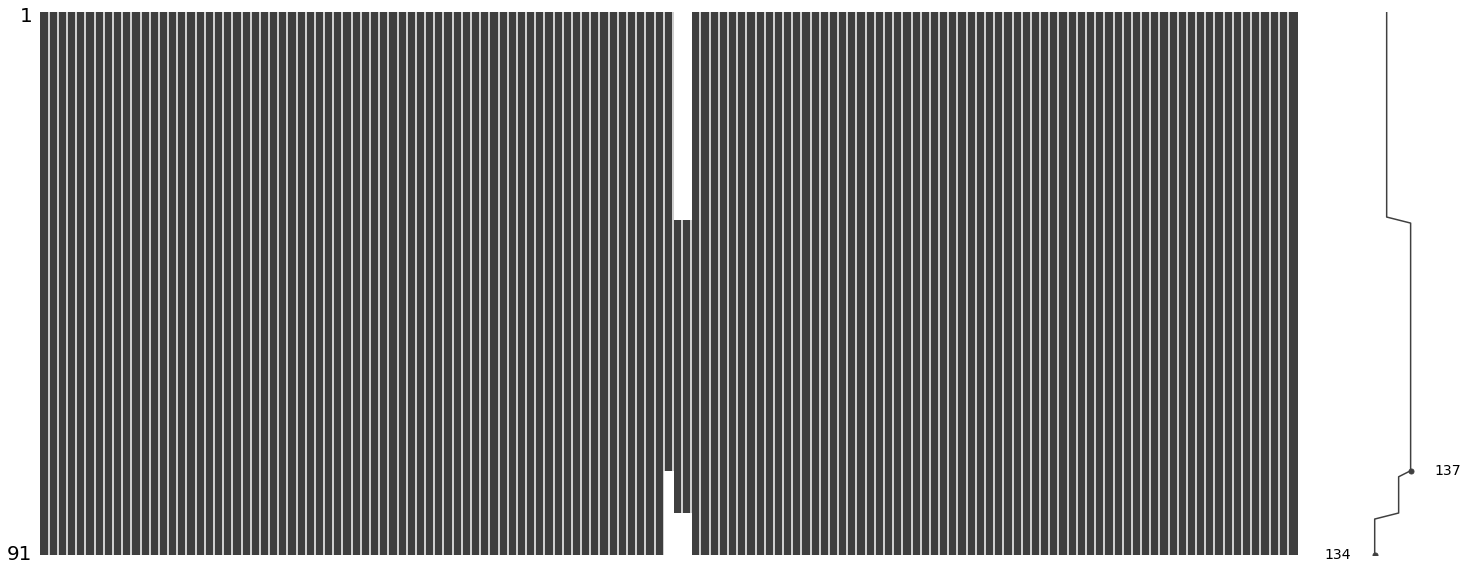

In [15]:
missingno.matrix(dataset_annual)

In [16]:
missing = describe_dataframe(dataset_annual, remove_zeros=True)
missing

,Column,Missing
0,MIO_EUR,15.3846
1,L_TOTAL,46.1538
2,UNL_TOTAL,46.1538


In [17]:
dataset_annual.head(15)

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2010,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,0.474099,0.202110,-0.245552,-0.202110,0.467210,0.197819,-0.242613,-0.197819,0.053380,0.051146,0.038996,0.051146,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,14.575072,19.637876,9.512269,5.752902,24.398788,4.615097,3.966224,9.749093,10.329550,6.445564,6.547262,15.823776,16.649203,2.783239,1.327979,3.674409,4.009897,4.382880,132.177612,30.650043,60.779869,780.556021,11806.0,44835.0,13866.0,70507.0,11360.0,44584.0,16384.0,72328.0,2016.25,NaN,NaN,18028.909091,49,4.053816,6.095815,9.798023,16.614763,0.306789,-0.138970,0.153101,-0.153101,0.299181,-0.144685,0.139387,-0.139387,0.042870,0.048620,0.046756,0.046756,4.053816,12.714621,22.854273,26.302324,0.467335,-0.264430,0.183711,-0.183711,0.462333,-0.265378,0.176747,-0.176747,0.049947,0.037574,0.048033,0.048033,4.053816,16.345998,26.201021,33.540369,0.513696,-0.298184,0.196802,-0.196802,0.507719,-0.296658,0.191635,-0.191635,0.055679,0.034079,0.052140,0.052140,4.017889,14.575072,26.201021,52.594557,0.474099,-0.245552,0.202110,-0.202110,0.467210,-0.242613,0.197819,-0.197819,0.053380,0.038996,0.051146,0.051146
1,2010,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,0.340091,0.150633,-0.167727,-0.150633,0.332144,0.150750,-0.159501,-0.150750,0.056088,0.058329,0.060716,0.058329,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,16.021933,21.771944,10.271922,6.309107,26.758911,4.995527,5.543553,10.462152,11.000190,8.112464,8.700703,16.767439,17.419203,1.878589,2.386402,4.156865,4.581177,3.723859,112.269660,26.020222,51.751401,659.921030,87330.0,375115.0,82051.0,544496.0,84172.0,402246.0,107376.0,593794.0,19627.51,NaN,NaN,16320.850394,81,4.816764,7.030397,10.519632,13.670895,0.245236,0.030018,0.236393,-0.236393,0.241640,0.031126,0.234157,-0.234157,0.048755,0.076113,0.060924,0.060924,4.816764,13.515330,23.514276,22.845725,0.337155,-0.120451,0.190933,-0.190933,0.329974,-0.115169,0.188722,-0.188722,0.051948,0.059625,0.055771,0.055771,4.816764,17.777812,29.026246,28.046688,0.348850,-0.177214,0.153486,-0.153486,0.341657,-0.168365,0.154419,-0.154419,0.054679,0.057935,0.057141,0.057141,4.816764,16.021933,29.026246,44.686314,0.340091,-0.167727,0.150633,-0.150633,0.332144,-0.159501,0.150750,-0.150750,0.056088,0.060716,0.058329,0.058329
2,2010,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,0.327792,0.161695,-0.152513,-0.161695,0.330502,0.159993,-0.157

In [18]:
dataset_annual.cases.sum()

863

In [19]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'MIO_EUR']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['MIO_EUR']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [20]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'L_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['L_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [21]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'UNL_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['UNL_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

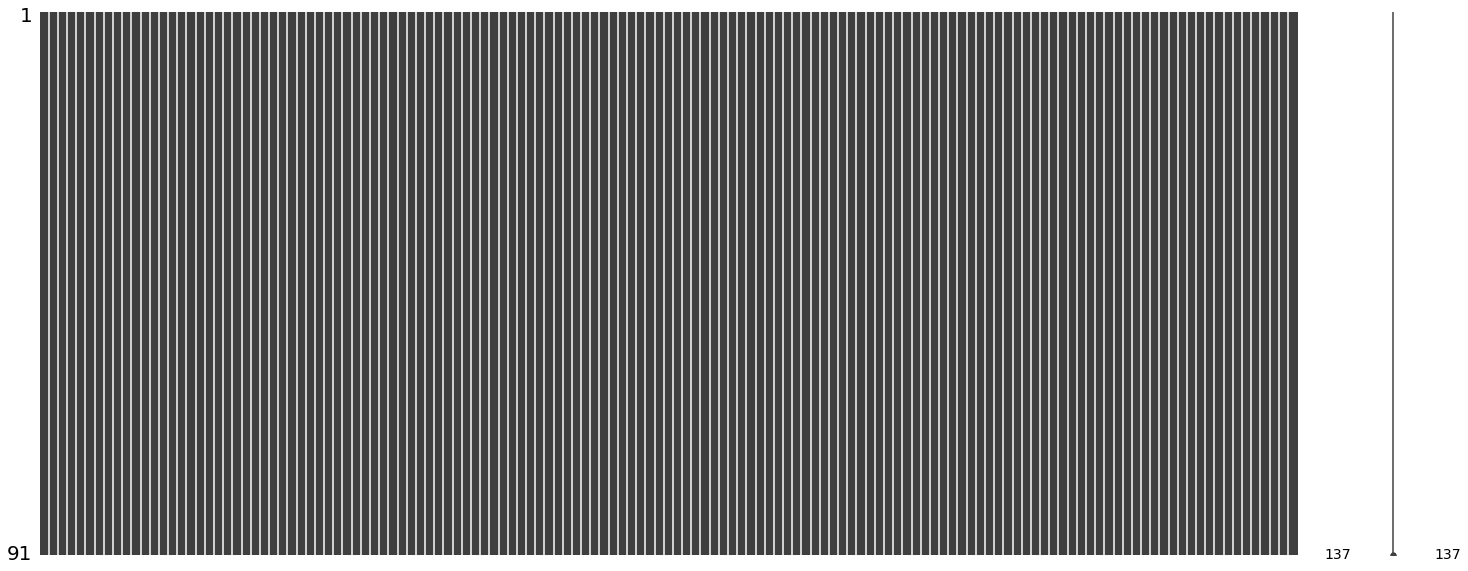

In [22]:
missingno.matrix(dataset_annual)

<AxesSubplot:>

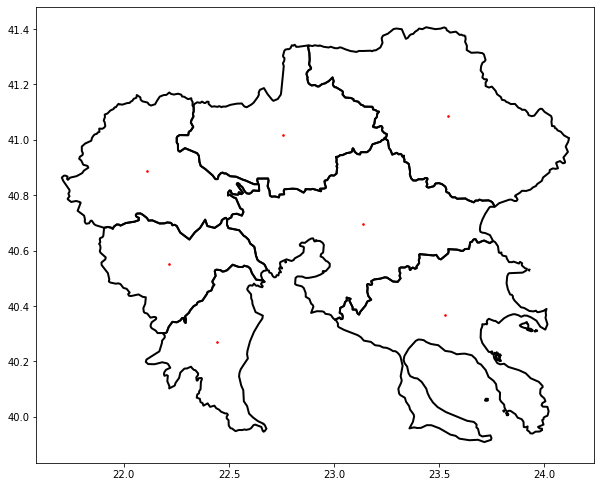

In [23]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(dataset_annual[['NUTS3_NAME']], geometry=gpd.points_from_xy(dataset_annual.x, dataset_annual.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [24]:
data_q1 = []
data_q2 = []
data_q3 = []
data_q4 = []

for year in years[1:]:
    for region in nuts3_units:

        df_preceding = dataset_annual.loc[(dataset_annual['year'] == year-1) & (dataset_annual['NUTS3_NAME'] == region)]
        df_current = dataset_annual.loc[(dataset_annual['year'] == year) & (dataset_annual['NUTS3_NAME'] == region)]

        data_q1.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q1': df_current.min_temp_q1.iloc[0],
                        'mean_temp_q1': df_current.mean_temp_q1.iloc[0],
                        'max_temp_q1': df_current.max_temp_q1.iloc[0],
                        'prec_q1': df_current.prec_q1.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q1': df_current.ndvi_q1.iloc[0],
                        'ndwi_q1': df_current.ndwi_q1.iloc[0],
                        'ndmi_q1': df_current.ndmi_q1.iloc[0],
                        'ndbi_q1': df_current.ndbi_q1.iloc[0],
                        'ndvi_mean_q1': df_current.ndvi_mean_q1.iloc[0],
                        'ndwi_mean_q1': df_current.ndwi_mean_q1.iloc[0],
                        'ndmi_mean_q1': df_current.ndmi_mean_q1.iloc[0],
                        'ndbi_mean_q1': df_current.ndbi_mean_q1.iloc[0],
                        'ndvi_std_q1': df_current.ndvi_std_q1.iloc[0],
                        'ndwi_std_q1': df_current.ndwi_std_q1.iloc[0],
                        'ndmi_std_q1': df_current.ndmi_std_q1.iloc[0],
                        'ndbi_std_q1': df_current.ndbi_std_q1.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q2.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q2': df_current.min_temp_q2.iloc[0],
                        'mean_temp_q2': df_current.mean_temp_q2.iloc[0],
                        'max_temp_q2': df_current.max_temp_q2.iloc[0],
                        'prec_q2': df_current.prec_q2.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q2': df_current.ndvi_q2.iloc[0],
                        'ndwi_q2': df_current.ndwi_q2.iloc[0],
                        'ndmi_q2': df_current.ndmi_q2.iloc[0],
                        'ndbi_q2': df_current.ndbi_q2.iloc[0],
                        'ndvi_mean_q2': df_current.ndvi_mean_q2.iloc[0],
                        'ndwi_mean_q2': df_current.ndwi_mean_q2.iloc[0],
                        'ndmi_mean_q2': df_current.ndmi_mean_q2.iloc[0],
                        'ndbi_mean_q2': df_current.ndbi_mean_q2.iloc[0],
                        'ndvi_std_q2': df_current.ndvi_std_q2.iloc[0],
                        'ndwi_std_q2': df_current.ndwi_std_q2.iloc[0],
                        'ndmi_std_q2': df_current.ndmi_std_q2.iloc[0],
                        'ndbi_std_q2': df_current.ndbi_std_q2.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q3.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q3': df_current.min_temp_q3.iloc[0],
                        'mean_temp_q3': df_current.mean_temp_q3.iloc[0],
                        'max_temp_q3': df_current.max_temp_q3.iloc[0],
                        'prec_q3': df_current.prec_q3.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q3': df_current.ndvi_q3.iloc[0],
                        'ndwi_q3': df_current.ndwi_q3.iloc[0],
                        'ndmi_q3': df_current.ndmi_q3.iloc[0],
                        'ndbi_q3': df_current.ndbi_q3.iloc[0],
                        'ndvi_mean_q3': df_current.ndvi_mean_q3.iloc[0],
                        'ndwi_mean_q3': df_current.ndwi_mean_q3.iloc[0],
                        'ndmi_mean_q3': df_current.ndmi_mean_q3.iloc[0],
                        'ndbi_mean_q3': df_current.ndbi_mean_q3.iloc[0],
                        'ndvi_std_q3': df_current.ndvi_std_q3.iloc[0],
                        'ndwi_std_q3': df_current.ndwi_std_q3.iloc[0],
                        'ndmi_std_q3': df_current.ndmi_std_q3.iloc[0],
                        'ndbi_std_q3': df_current.ndbi_std_q3.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q4.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q4': df_current.min_temp_q4.iloc[0],
                        'mean_temp_q4': df_current.mean_temp_q4.iloc[0],
                        'max_temp_q4': df_current.max_temp_q4.iloc[0],
                        'prec_q4': df_current.prec_q4.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q4': df_current.ndvi_q4.iloc[0],
                        'ndwi_q4': df_current.ndwi_q4.iloc[0],
                        'ndmi_q4': df_current.ndmi_q4.iloc[0],
                        'ndbi_q4': df_current.ndbi_q4.iloc[0],
                        'ndvi_mean_q4': df_current.ndvi_mean_q4.iloc[0],
                        'ndwi_mean_q4': df_current.ndwi_mean_q4.iloc[0],
                        'ndmi_mean_q4': df_current.ndmi_mean_q4.iloc[0],
                        'ndbi_mean_q4': df_current.ndbi_mean_q4.iloc[0],
                        'ndvi_std_q4': df_current.ndvi_std_q4.iloc[0],
                        'ndwi_std_q4': df_current.ndwi_std_q4.iloc[0],
                        'ndmi_std_q4': df_current.ndmi_std_q4.iloc[0],
                        'ndbi_std_q4': df_current.ndbi_std_q4.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
df_q1 = pd.DataFrame(data_q1)
df_q2 = pd.DataFrame(data_q2)   
df_q3 = pd.DataFrame(data_q3)   
df_q4 = pd.DataFrame(data_q4)   

In [25]:
df_q1

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3.154111,6.229173,9.327499,7.851225,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.253413,0.164233,0.382909,-0.382909,0.243740,0.189907,0.401026,-0.401026,0.044376,0.051454,0.050562,0.050562,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.250,5025.2,5265.4,18028.909091,6
1,2011,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,3.805192,6.833876,9.632381,7.258680,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.331371,-0.125325,0.181410,-0.181410,0.328781,-0.127656,0.175605,-0.175605,0.053834,0.060592,0.055271,0.055271,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.510,9804.6,10058.8,16320.850394,10
2,2011,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.615530,7.183375,10.120540,4.959644,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.238927,-0.089832,0.144111,-0.144111,0.241070,-0.091286,0.144951,-0.144951,0.023444,0.040297,0.033327,0.033327,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.520,5809.2,5920.4,14407.043956,0
3,2011,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.344699,6.643856,9.787595,6.495086,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.257757,0.126741,0.363656,-0.363656,0.254301,0.126465,0.361181,-0.361181,0.039384,0.052719,0.050437,0.050437,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.340,5025.2,5265.4,15360.034091,8
4,2011,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.506731,6.992178,8.838208,9.737422,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.269825,0.101198,0.347946,-0.347946,0.258944,0.119827,0.353585,-0.353585,0.044928,0.065635,0.063431,0.063431,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.030,5025.2,5265.4,18910.088889,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,2022,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.870068,6.293356,7.509843,5.442580,17.791667,22.583333,45.166667,956.665215,44.0,-6.0,50.0,8.833333,28.166667,29.166667,5.666667,1333.0,348.0,24.0,95.733373,569.0,119.0,128.0,543.0,0.333965,-0.319067,0.001807,-0.001807,0.329843,-0.312747,0.012483,-0.012483,0.048371,0.042898,0.049562,0.049562,40713.0,5585.0,26233.0,8895.0,38884.0,5279.0,22456.0,11149.0,3994.366,993.0,1124.0,20932.076923,13
80,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,5.743271,6.977415,6.377679,16.500000,19.833333,46.124031,852.802865,38.0,-5.0,43.0,8.333333,25.333333,26.166667,5.500000,1113.0,356.0,29.0,94.766077,512.0,133.0,140.0,509.0,0.328245,-0.296437,0.083696,-0.083696,0.314409,-0.284335,0.092313,-0.092313,0.046038,0.045839,0.048897,0.048897,66761.0,8995.0,42431.0,15335.0,68651.0,8423.0,41817.0,18411.0,3934.476,3152.0,3160.0,29653.488636,18
81,2022,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.680987,6.396567,7.566929,13.41743

In [26]:
df_q2

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3.154111,12.097793,22.088223,15.960073,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.394975,-0.098896,0.267729,-0.267729,0.382164,-0.078352,0.276253,-0.276253,0.048593,0.041631,0.049521,0.049521,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.250,5025.2,5265.4,18028.909091,6
1,2011,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,3.805192,12.830514,23.918140,14.867867,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.387596,-0.199612,0.167090,-0.167090,0.381656,-0.197207,0.162939,-0.162939,0.057431,0.054866,0.057131,0.057131,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.510,9804.6,10058.8,16320.850394,10
2,2011,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.615530,12.999527,23.860639,13.415651,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.352244,-0.203715,0.140172,-0.140172,0.353925,-0.201050,0.144321,-0.144321,0.040820,0.036226,0.045219,0.045219,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.520,5809.2,5920.4,14407.043956,0
3,2011,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.344699,12.227370,22.200690,14.836663,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.398693,-0.121504,0.252789,-0.252789,0.397168,-0.119271,0.253801,-0.253801,0.044564,0.043556,0.048887,0.048887,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.340,5025.2,5265.4,15360.034091,8
4,2011,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.506731,12.380341,23.070868,17.260490,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.400474,-0.120991,0.255178,-0.255178,0.396265,-0.105561,0.264551,-0.264551,0.052447,0.048405,0.059482,0.059482,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.030,5025.2,5265.4,18910.088889,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,2022,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.870068,13.534164,26.271743,17.189118,17.791667,22.583333,45.166667,956.665215,44.0,-6.0,50.0,8.833333,28.166667,29.166667,5.666667,1333.0,348.0,24.0,95.733373,569.0,119.0,128.0,543.0,0.405305,-0.377911,0.059549,-0.059549,0.399714,-0.370469,0.072114,-0.072114,0.050981,0.039628,0.050767,0.050767,40713.0,5585.0,26233.0,8895.0,38884.0,5279.0,22456.0,11149.0,3994.366,993.0,1124.0,20932.076923,13
80,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,12.904360,24.860368,19.158368,16.500000,19.833333,46.124031,852.802865,38.0,-5.0,43.0,8.333333,25.333333,26.166667,5.500000,1113.0,356.0,29.0,94.766077,512.0,133.0,140.0,509.0,0.418398,-0.368236,0.116090,-0.116090,0.405268,-0.356941,0.123872,-0.123872,0.049696,0.043289,0.048734,0.048734,66761.0,8995.0,42431.0,15335.0,68651.0,8423.0,41817.0,18411.0,3934.476,3152.0,3160.0,29653.488636,18
81,2022,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.680987,

In [27]:
df_q3

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3.154111,16.140356,25.591355,21.290235,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.454731,-0.183245,0.246524,-0.246524,0.444107,-0.170003,0.250130,-0.250130,0.054694,0.037628,0.055227,0.055227,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.250,5025.2,5265.4,18028.909091,6
1,2011,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,3.805192,17.421654,27.999990,21.668700,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.378583,-0.233879,0.132150,-0.132150,0.373756,-0.230329,0.130451,-0.130451,0.059430,0.054023,0.059993,0.059993,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.510,9804.6,10058.8,16320.850394,10
2,2011,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.615530,17.769485,28.501489,19.865039,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.356537,-0.260447,0.098562,-0.098562,0.356282,-0.257762,0.100835,-0.100835,0.047118,0.033747,0.050085,0.050085,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.520,5809.2,5920.4,14407.043956,0
3,2011,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.344699,16.496359,26.274069,20.873664,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.442904,-0.203153,0.219985,-0.219985,0.440181,-0.201061,0.219940,-0.219940,0.050468,0.039873,0.053010,0.053010,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.340,5025.2,5265.4,15360.034091,8
4,2011,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.506731,16.849642,26.986681,22.586039,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.418954,-0.198718,0.206012,-0.206012,0.415985,-0.185722,0.213826,-0.213826,0.059560,0.043850,0.062738,0.062738,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.030,5025.2,5265.4,18910.088889,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,2022,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.870068,17.869145,29.729922,32.214537,17.791667,22.583333,45.166667,956.665215,44.0,-6.0,50.0,8.833333,28.166667,29.166667,5.666667,1333.0,348.0,24.0,95.733373,569.0,119.0,128.0,543.0,0.380575,-0.353715,0.045631,-0.045631,0.374135,-0.347317,0.051210,-0.051210,0.051899,0.040313,0.050939,0.050939,40713.0,5585.0,26233.0,8895.0,38884.0,5279.0,22456.0,11149.0,3994.366,993.0,1124.0,20932.076923,13
80,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,16.529329,26.270436,34.438744,16.500000,19.833333,46.124031,852.802865,38.0,-5.0,43.0,8.333333,25.333333,26.166667,5.500000,1113.0,356.0,29.0,94.766077,512.0,133.0,140.0,509.0,0.467423,-0.404333,0.136607,-0.136607,0.456880,-0.394823,0.145231,-0.145231,0.051933,0.042960,0.050224,0.050224,66761.0,8995.0,42431.0,15335.0,68651.0,8423.0,41817.0,18411.0,3934.476,3152.0,3160.0,29653.488636,18
81,2022,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.680987,

In [28]:
df_q4

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3.154111,14.223628,25.591355,28.895104,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.432228,-0.191898,0.211617,-0.211617,0.424010,-0.182173,0.214168,-0.214168,0.053919,0.044251,0.055660,0.055660,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.250,5025.2,5265.4,18028.909091,6
1,2011,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,3.805192,15.435054,27.999990,29.007087,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.353578,-0.225764,0.113143,-0.113143,0.348423,-0.220696,0.112827,-0.112827,0.057399,0.055858,0.059573,0.059573,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.510,9804.6,10058.8,16320.850394,10
2,2011,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.615530,15.723245,28.501489,26.323597,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.327438,-0.264258,0.065333,-0.065333,0.325676,-0.259052,0.068566,-0.068566,0.045403,0.036113,0.049661,0.049661,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.520,5809.2,5920.4,14407.043956,0
3,2011,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.344699,14.528362,26.274069,27.906690,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.424816,-0.215859,0.185423,-0.185423,0.420959,-0.214166,0.184196,-0.184196,0.049920,0.046201,0.053686,0.053686,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.340,5025.2,5265.4,15360.034091,8
4,2011,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.506731,15.191683,26.986681,31.370513,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.394203,-0.203081,0.172731,-0.172731,0.389829,-0.188996,0.179900,-0.179900,0.060100,0.052936,0.065038,0.065038,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.030,5025.2,5265.4,18910.088889,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,2022,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.870068,16.570022,29.729922,35.693625,17.791667,22.583333,45.166667,956.665215,44.0,-6.0,50.0,8.833333,28.166667,29.166667,5.666667,1333.0,348.0,24.0,95.733373,569.0,119.0,128.0,543.0,0.353906,-0.326138,0.032370,-0.032370,0.344765,-0.318583,0.036705,-0.036705,0.048984,0.038971,0.048227,0.048227,40713.0,5585.0,26233.0,8895.0,38884.0,5279.0,22456.0,11149.0,3994.366,993.0,1124.0,20932.076923,13
80,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,15.322118,26.270436,38.160645,16.500000,19.833333,46.124031,852.802865,38.0,-5.0,43.0,8.333333,25.333333,26.166667,5.500000,1113.0,356.0,29.0,94.766077,512.0,133.0,140.0,509.0,0.457060,-0.390460,0.130376,-0.130376,0.445318,-0.379004,0.138167,-0.138167,0.050872,0.043102,0.048762,0.048762,66761.0,8995.0,42431.0,15335.0,68651.0,8423.0,41817.0,18411.0,3934.476,3152.0,3160.0,29653.488636,18
81,2022,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.680987,

In [29]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

613
613
613
613


In [30]:
df_q1 = convert_multiple_cases(df_q1, target_col='WNV_cases')
df_q2 = convert_multiple_cases(df_q2, target_col='WNV_cases')
df_q3 = convert_multiple_cases(df_q3, target_col='WNV_cases')
df_q4 = convert_multiple_cases(df_q4, target_col='WNV_cases')

In [31]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

613
613
613
613


In [32]:
df_q1

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3.154111,6.229173,9.327499,7.851225,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.253413,0.164233,0.382909,-0.382909,0.243740,0.189907,0.401026,-0.401026,0.044376,0.051454,0.050562,0.050562,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.250,5025.2,5265.4,18028.909091,1
1,2011,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,3.805192,6.833876,9.632381,7.258680,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.331371,-0.125325,0.181410,-0.181410,0.328781,-0.127656,0.175605,-0.175605,0.053834,0.060592,0.055271,0.055271,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.510,9804.6,10058.8,16320.850394,1
2,2011,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.615530,7.183375,10.120540,4.959644,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.238927,-0.089832,0.144111,-0.144111,0.241070,-0.091286,0.144951,-0.144951,0.023444,0.040297,0.033327,0.033327,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.520,5809.2,5920.4,14407.043956,0
3,2011,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.344699,6.643856,9.787595,6.495086,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.257757,0.126741,0.363656,-0.363656,0.254301,0.126465,0.361181,-0.361181,0.039384,0.052719,0.050437,0.050437,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.340,5025.2,5265.4,15360.034091,1
4,2011,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.506731,6.992178,8.838208,9.737422,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.269825,0.101198,0.347946,-0.347946,0.258944,0.119827,0.353585,-0.353585,0.044928,0.065635,0.063431,0.063431,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.030,5025.2,5265.4,18910.088889,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
647,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,5.743271,6.977415,6.377679,16.500000,19.833333,46.124031,852.802865,38.0,-5.0,43.0,8.333333,25.333333,26.166667,5.500000,1113.0,356.0,29.0,94.766077,512.0,133.0,140.0,509.0,0.328245,-0.296437,0.083696,-0.083696,0.314409,-0.284335,0.092313,-0.092313,0.046038,0.045839,0.048897,0.048897,66761.0,8995.0,42431.0,15335.0,68651.0,8423.0,41817.0,18411.0,3934.476,3152.0,3160.0,29653.488636,1
648,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,5.743271,6.977415,6.377679,16.500000,19.833333,46.124031,852.802865,38.0,-5.0,43.0,8.333333,25.333333,26.166667,5.500000,1113.0,356.0,29.0,94.766077,512.0,133.0,140.0,509.0,0.328245,-0.296437,0.083696,-0.083696,0.314409,-0.284335,0.092313,-0.092313,0.046038,0.045839,0.048897,0.048897,66761.0,8995.0,42431.0,15335.0,68651.0,8423.0,41817.0,18411.0,3934.476,3152.0,3160.0,29653.488636,1
649,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,5.743271,6.977415,6.377679

In [33]:
df_q2

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3.154111,12.097793,22.088223,15.960073,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.394975,-0.098896,0.267729,-0.267729,0.382164,-0.078352,0.276253,-0.276253,0.048593,0.041631,0.049521,0.049521,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.250,5025.2,5265.4,18028.909091,1
1,2011,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,3.805192,12.830514,23.918140,14.867867,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.387596,-0.199612,0.167090,-0.167090,0.381656,-0.197207,0.162939,-0.162939,0.057431,0.054866,0.057131,0.057131,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.510,9804.6,10058.8,16320.850394,1
2,2011,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.615530,12.999527,23.860639,13.415651,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.352244,-0.203715,0.140172,-0.140172,0.353925,-0.201050,0.144321,-0.144321,0.040820,0.036226,0.045219,0.045219,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.520,5809.2,5920.4,14407.043956,0
3,2011,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.344699,12.227370,22.200690,14.836663,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.398693,-0.121504,0.252789,-0.252789,0.397168,-0.119271,0.253801,-0.253801,0.044564,0.043556,0.048887,0.048887,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.340,5025.2,5265.4,15360.034091,1
4,2011,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.506731,12.380341,23.070868,17.260490,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.400474,-0.120991,0.255178,-0.255178,0.396265,-0.105561,0.264551,-0.264551,0.052447,0.048405,0.059482,0.059482,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.030,5025.2,5265.4,18910.088889,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
647,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,12.904360,24.860368,19.158368,16.500000,19.833333,46.124031,852.802865,38.0,-5.0,43.0,8.333333,25.333333,26.166667,5.500000,1113.0,356.0,29.0,94.766077,512.0,133.0,140.0,509.0,0.418398,-0.368236,0.116090,-0.116090,0.405268,-0.356941,0.123872,-0.123872,0.049696,0.043289,0.048734,0.048734,66761.0,8995.0,42431.0,15335.0,68651.0,8423.0,41817.0,18411.0,3934.476,3152.0,3160.0,29653.488636,1
648,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,12.904360,24.860368,19.158368,16.500000,19.833333,46.124031,852.802865,38.0,-5.0,43.0,8.333333,25.333333,26.166667,5.500000,1113.0,356.0,29.0,94.766077,512.0,133.0,140.0,509.0,0.418398,-0.368236,0.116090,-0.116090,0.405268,-0.356941,0.123872,-0.123872,0.049696,0.043289,0.048734,0.048734,66761.0,8995.0,42431.0,15335.0,68651.0,8423.0,41817.0,18411.0,3934.476,3152.0,3160.0,29653.488636,1
649,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,

In [34]:
df_q3

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3.154111,16.140356,25.591355,21.290235,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.454731,-0.183245,0.246524,-0.246524,0.444107,-0.170003,0.250130,-0.250130,0.054694,0.037628,0.055227,0.055227,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.250,5025.2,5265.4,18028.909091,1
1,2011,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,3.805192,17.421654,27.999990,21.668700,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.378583,-0.233879,0.132150,-0.132150,0.373756,-0.230329,0.130451,-0.130451,0.059430,0.054023,0.059993,0.059993,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.510,9804.6,10058.8,16320.850394,1
2,2011,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.615530,17.769485,28.501489,19.865039,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.356537,-0.260447,0.098562,-0.098562,0.356282,-0.257762,0.100835,-0.100835,0.047118,0.033747,0.050085,0.050085,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.520,5809.2,5920.4,14407.043956,0
3,2011,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.344699,16.496359,26.274069,20.873664,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.442904,-0.203153,0.219985,-0.219985,0.440181,-0.201061,0.219940,-0.219940,0.050468,0.039873,0.053010,0.053010,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.340,5025.2,5265.4,15360.034091,1
4,2011,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.506731,16.849642,26.986681,22.586039,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.418954,-0.198718,0.206012,-0.206012,0.415985,-0.185722,0.213826,-0.213826,0.059560,0.043850,0.062738,0.062738,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.030,5025.2,5265.4,18910.088889,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
647,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,16.529329,26.270436,34.438744,16.500000,19.833333,46.124031,852.802865,38.0,-5.0,43.0,8.333333,25.333333,26.166667,5.500000,1113.0,356.0,29.0,94.766077,512.0,133.0,140.0,509.0,0.467423,-0.404333,0.136607,-0.136607,0.456880,-0.394823,0.145231,-0.145231,0.051933,0.042960,0.050224,0.050224,66761.0,8995.0,42431.0,15335.0,68651.0,8423.0,41817.0,18411.0,3934.476,3152.0,3160.0,29653.488636,1
648,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,16.529329,26.270436,34.438744,16.500000,19.833333,46.124031,852.802865,38.0,-5.0,43.0,8.333333,25.333333,26.166667,5.500000,1113.0,356.0,29.0,94.766077,512.0,133.0,140.0,509.0,0.467423,-0.404333,0.136607,-0.136607,0.456880,-0.394823,0.145231,-0.145231,0.051933,0.042960,0.050224,0.050224,66761.0,8995.0,42431.0,15335.0,68651.0,8423.0,41817.0,18411.0,3934.476,3152.0,3160.0,29653.488636,1
649,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,

In [35]:
df_q4

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3.154111,14.223628,25.591355,28.895104,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.432228,-0.191898,0.211617,-0.211617,0.424010,-0.182173,0.214168,-0.214168,0.053919,0.044251,0.055660,0.055660,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.250,5025.2,5265.4,18028.909091,1
1,2011,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,3.805192,15.435054,27.999990,29.007087,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.353578,-0.225764,0.113143,-0.113143,0.348423,-0.220696,0.112827,-0.112827,0.057399,0.055858,0.059573,0.059573,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.510,9804.6,10058.8,16320.850394,1
2,2011,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.615530,15.723245,28.501489,26.323597,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.327438,-0.264258,0.065333,-0.065333,0.325676,-0.259052,0.068566,-0.068566,0.045403,0.036113,0.049661,0.049661,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.520,5809.2,5920.4,14407.043956,0
3,2011,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.344699,14.528362,26.274069,27.906690,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.424816,-0.215859,0.185423,-0.185423,0.420959,-0.214166,0.184196,-0.184196,0.049920,0.046201,0.053686,0.053686,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.340,5025.2,5265.4,15360.034091,1
4,2011,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.506731,15.191683,26.986681,31.370513,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.394203,-0.203081,0.172731,-0.172731,0.389829,-0.188996,0.179900,-0.179900,0.060100,0.052936,0.065038,0.065038,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.030,5025.2,5265.4,18910.088889,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
647,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,15.322118,26.270436,38.160645,16.500000,19.833333,46.124031,852.802865,38.0,-5.0,43.0,8.333333,25.333333,26.166667,5.500000,1113.0,356.0,29.0,94.766077,512.0,133.0,140.0,509.0,0.457060,-0.390460,0.130376,-0.130376,0.445318,-0.379004,0.138167,-0.138167,0.050872,0.043102,0.048762,0.048762,66761.0,8995.0,42431.0,15335.0,68651.0,8423.0,41817.0,18411.0,3934.476,3152.0,3160.0,29653.488636,1
648,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,15.322118,26.270436,38.160645,16.500000,19.833333,46.124031,852.802865,38.0,-5.0,43.0,8.333333,25.333333,26.166667,5.500000,1113.0,356.0,29.0,94.766077,512.0,133.0,140.0,509.0,0.457060,-0.390460,0.130376,-0.130376,0.445318,-0.379004,0.138167,-0.138167,0.050872,0.043102,0.048762,0.048762,66761.0,8995.0,42431.0,15335.0,68651.0,8423.0,41817.0,18411.0,3934.476,3152.0,3160.0,29653.488636,1
649,2022,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.771721,

In [36]:
df_q1.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q1_2011_2022.csv", encoding = enc, index = False)
df_q2.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q2_2011_2022.csv", encoding = enc, index = False)
df_q3.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q3_2011_2022.csv", encoding = enc, index = False)
df_q4.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q4_2011_2022.csv", encoding = enc, index = False)